In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
df = pd.read_csv('breast-cancer-wisconsin-data.csv')
print(df.head())
df.describe(include="all")

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perimeter_worst  area_wor

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
unique,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,357,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,3.037183e+07,NaN,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,NaN,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,NaN,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,NaN,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,NaN,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,NaN,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080


In [4]:
# M = ממאיר, B = שפיר
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

In [5]:
X = df.drop(columns=["id", "diagnosis"]).copy()
y = df['diagnosis']

In [6]:
from sklearn.preprocessing import StandardScaler

3# Normalize the data
scaler = StandardScaler()
scaler.fit(X)
X_scaled = scaler.transform(X)

df_feat = pd.DataFrame(X_scaled, columns=X.columns)

In [12]:
from sklearn import model_selection

X_train, X_test, y_train, y_test = model_selection.train_test_split(df_feat, y, test_size=0.35, random_state=101)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       125
           1       0.99      0.95      0.97        75

    accuracy                           0.97       200
   macro avg       0.98      0.97      0.97       200
weighted avg       0.98      0.97      0.97       200



<Axes: >

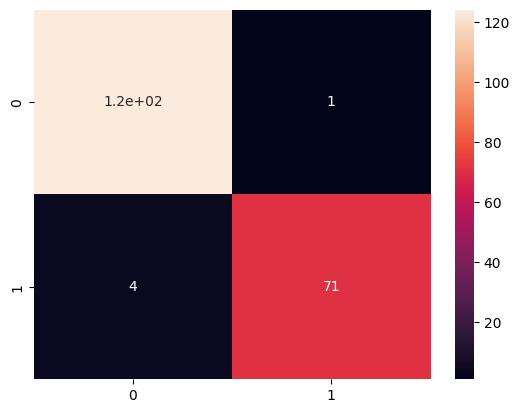

In [15]:
from sklearn import linear_model
from sklearn.metrics import classification_report,confusion_matrix

LR = linear_model.LogisticRegression(random_state=0).fit(X_train, y_train)
predictions = LR.predict(X_test)
print(classification_report(y_test, predictions))

sns.heatmap(confusion_matrix(y_test, LR.predict(X_test)), annot=True)

In [21]:
from sklearn.model_selection import GridSearchCV

grid_params = {"C" : np.logspace(-3,2,10) }

gs = GridSearchCV(linear_model.LogisticRegression(random_state=0, solver="lbfgs", max_iter=500), grid_params, scoring="accuracy", cv=3, verbose=1)
g_res = gs.fit(X_train, y_train)
print(g_res.best_score_, g_res.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
0.983739837398374 {'C': np.float64(0.1668100537200059)}


In [22]:
best_LR = linear_model.LogisticRegression(random_state=0, solver="lbfgs", max_iter=500, C=0.16681, penalty="l2").fit(X_train, y_train)
predictions = best_LR.predict(X_test)
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.95      1.00      0.98       125
           1       1.00      0.92      0.96        75

    accuracy                           0.97       200
   macro avg       0.98      0.96      0.97       200
weighted avg       0.97      0.97      0.97       200



C:\Users\משתמש\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


### Save the model

In [2]:
# Save the model
import pickle
pickle.dump(best_LR, open('model.pkl', 'wb'))

NameError: name 'best_LR' is not defined